In [1]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

df_sales = pd.read_csv(r'C:\Sales Analysis\data\processed\cleaned_sales.csv')
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_sales.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,IsCancelled,Revenue
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490,United Kingdom,False,257.64
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069,United Kingdom,False,383.40
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069,United Kingdom,False,138.36
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069,United Kingdom,False,127.80
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069,United Kingdom,False,71.64


In [2]:
print(f"Total revenue: £{df_sales['Revenue'].sum():,.2f}")
print(f"Total orders: {df_sales['TransactionNo'].nunique():,}")
print(f"Total customers: {df_sales['CustomerNo'].nunique():,}")
print(f"Date range: {df_sales['Date'].min()} to {df_sales['Date'].max()}")

Total revenue: £62,965,892.34
Total orders: 19,789
Total customers: 4,718
Date range: 2018-12-01 00:00:00 to 2019-12-09 00:00:00


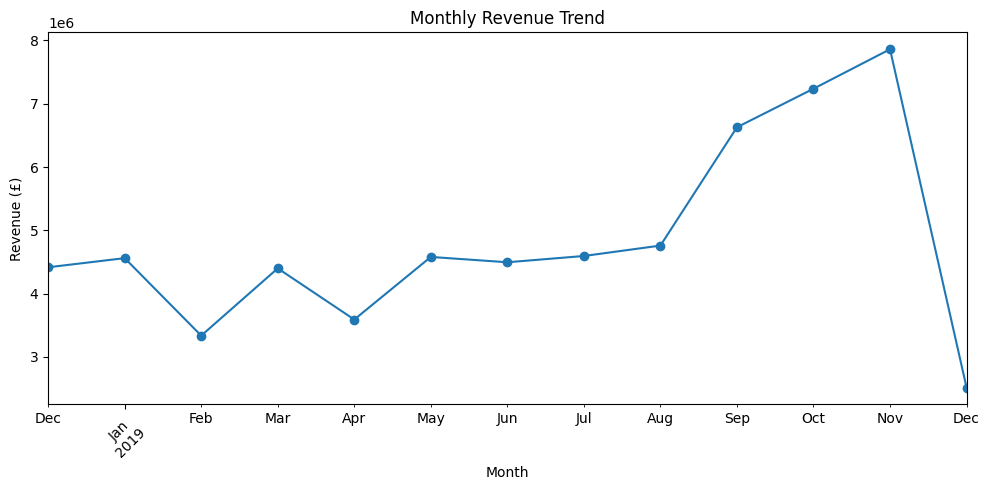

In [3]:
df_sales['Month'] = df_sales['Date'].dt.to_period('M')
monthly_rev = df_sales.groupby('Month')['Revenue'].sum()

plt.figure(figsize=(10,5))
monthly_rev.plot(kind='line', marker='o')
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue (£)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r'C:\Sales Analysis\output\figures\monthly_revenue_trend.png')
plt.show()

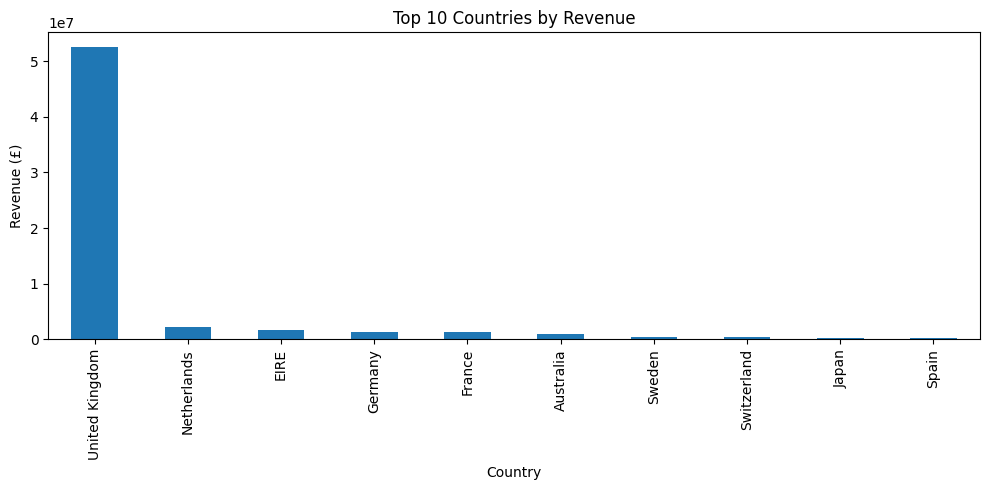

Country
United Kingdom    52524576.47
Netherlands        2151553.59
EIRE               1713410.95
Germany            1371543.27
France             1330652.89
Australia           995607.91
Sweden              401879.89
Switzerland         361969.25
Japan               293155.44
Spain               281012.27
Name: Revenue, dtype: float64


In [4]:
country_rev = df_sales.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
country_rev.head(10).plot(kind='bar')
plt.title('Top 10 Countries by Revenue')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig(r'C:\Sales Analysis\output\figures\top_countries_revenue.png')
plt.show()

print(country_rev.head(10))

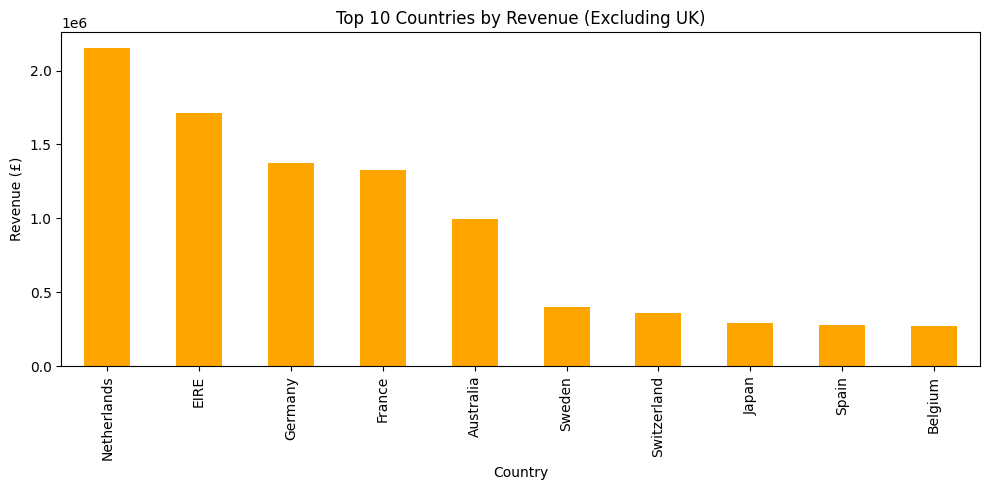

In [5]:
country_rev_intl = country_rev.drop('United Kingdom')

plt.figure(figsize=(10,5))
country_rev_intl.head(10).plot(kind='bar', color='orange')
plt.title('Top 10 Countries by Revenue (Excluding UK)')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig(r'C:\Sales Analysis\output\figures\top_countries_revenue_excl_uk.png')
plt.show()

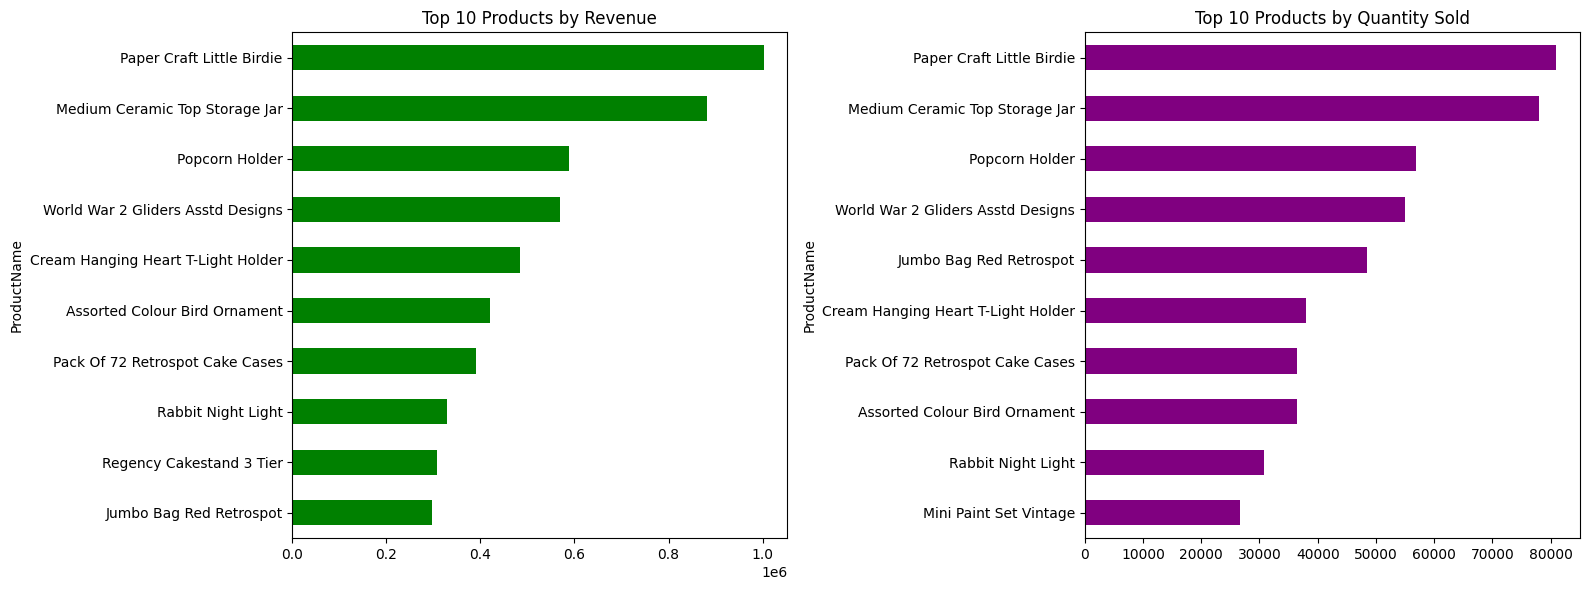

In [6]:
top_rev = df_sales.groupby('ProductName')['Revenue'].sum().sort_values(ascending=False).head(10)
top_qty = df_sales.groupby('ProductName')['Quantity'].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16,6))
top_rev.plot(kind='barh', ax=axes[0], color='green')
axes[0].set_title('Top 10 Products by Revenue')
axes[0].invert_yaxis()

top_qty.plot(kind='barh', ax=axes[1], color='purple')
axes[1].set_title('Top 10 Products by Quantity Sold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(r'C:\Sales Analysis\output\figures\top_products.png')
plt.show()

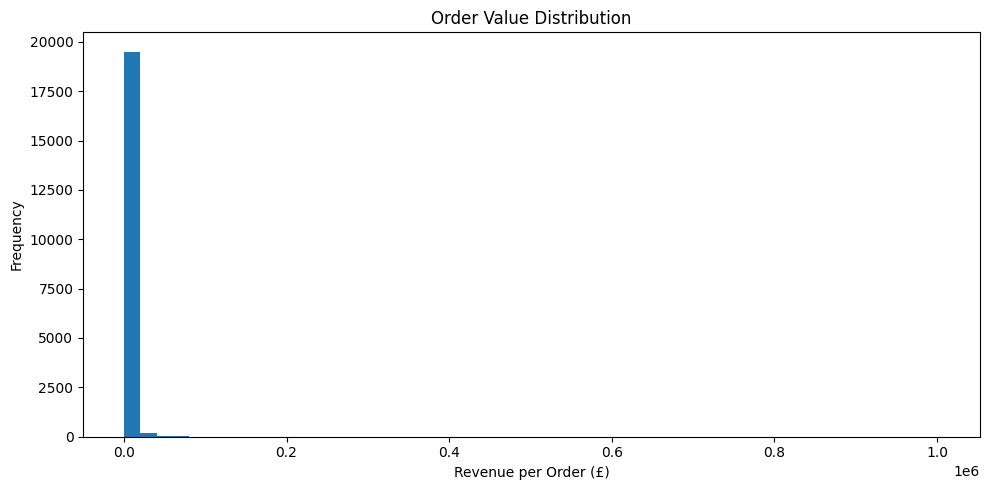

count    1.978900e+04
mean     3.181863e+03
std      1.126987e+04
min      5.460000e+00
25%      8.301600e+02
50%      1.717000e+03
75%      3.312130e+03
max      1.002718e+06
Name: Revenue, dtype: float64


In [7]:
order_value = df_sales.groupby('TransactionNo')['Revenue'].sum()

plt.figure(figsize=(10,5))
order_value.plot(kind='hist', bins=50)
plt.title('Order Value Distribution')
plt.xlabel('Revenue per Order (£)')
plt.tight_layout()
plt.savefig(r'C:\Sales Analysis\output\figures\order_value_distribution.png')
plt.show()

print(order_value.describe())

In [8]:
print(order_value.describe())
print()
print("Top 10 highest-value orders:")
print(order_value.sort_values(ascending=False).head(10))

count    1.978900e+04
mean     3.181863e+03
std      1.126987e+04
min      5.460000e+00
25%      8.301600e+02
50%      1.717000e+03
75%      3.312130e+03
max      1.002718e+06
Name: Revenue, dtype: float64

Top 10 highest-value orders:
TransactionNo
581483    1002718.10
541431     840113.80
574941     184880.85
576365     184148.76
556917     172833.48
567423     161373.58
563076     159953.82
572035     153882.12
563614     137836.80
562439     135571.26
Name: Revenue, dtype: float64


In [9]:
print("Top 10 highest-value orders:")
print(order_value.sort_values(ascending=False).head(10))

Top 10 highest-value orders:
TransactionNo
581483    1002718.10
541431     840113.80
574941     184880.85
576365     184148.76
556917     172833.48
567423     161373.58
563076     159953.82
572035     153882.12
563614     137836.80
562439     135571.26
Name: Revenue, dtype: float64


In [10]:
suspect_orders = ['581483', '541431']

for order in suspect_orders:
    print(f"\n--- TransactionNo: {order} ---")
    print(df_sales[df_sales['TransactionNo'].astype(str) == order][['ProductName', 'Price', 'Quantity', 'Revenue', 'CustomerNo', 'Country']])


--- TransactionNo: 581483 ---
                   ProductName  Price  Quantity    Revenue  CustomerNo  \
142  Paper Craft Little Birdie  12.38     80995  1002718.1       16446   

            Country  
142  United Kingdom  

--- TransactionNo: 541431 ---
                           ProductName  Price  Quantity   Revenue  CustomerNo  \
466382  Medium Ceramic Top Storage Jar  11.32     74215  840113.8       12346   

               Country  
466382  United Kingdom  


In [11]:
outlier_orders = ['581483', '541431']

df_outliers = df_sales[df_sales['TransactionNo'].astype(str).isin(outlier_orders)].copy()
df_sales_clean = df_sales[~df_sales['TransactionNo'].astype(str).isin(outlier_orders)].copy()

print(f"Outlier orders removed: {len(df_outliers)} rows")
print(f"Remaining sales rows: {len(df_sales_clean)}")

df_sales_clean.to_csv(r'C:\Sales Analysis\data\processed\cleaned_sales_no_outliers.csv', index=False)

Outlier orders removed: 2 rows
Remaining sales rows: 527762


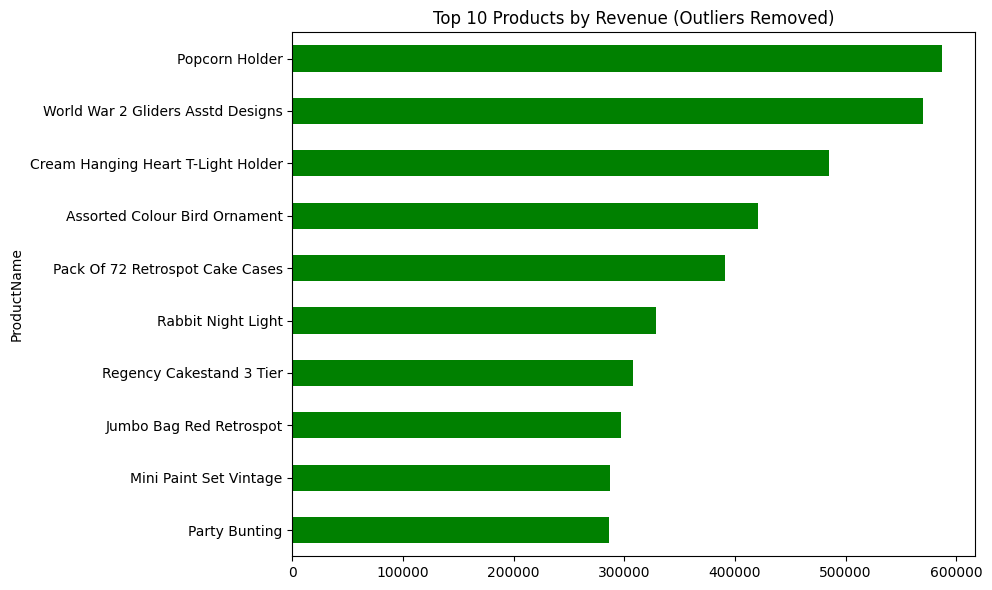

In [12]:
top_rev_clean = df_sales_clean.groupby('ProductName')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_rev_clean.plot(kind='barh', color='green')
plt.title('Top 10 Products by Revenue (Outliers Removed)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(r'C:\Sales Analysis\output\figures\top_products_revenue_no_outliers.png')
plt.show()